In [66]:
import glob2
import os
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from helperFunc import NormalizeImage, pad2match , loadNii, getID
import itk #Elastix
from scipy.ndimage import center_of_mass
from skimage.morphology import binary_closing, ball, dilation
from skimage.metrics import structural_similarity as ssim
import torch
from monai.metrics import DiceMetric, HausdorffDistanceMetric

### Load and normalize data

In [ ]:
idx = "000000000"
anonID = getID(idx, False)
pCT, CT, PT, Masks = loadNii(anonID,["ITV","avg_Lungs","LD_Lungs"])

In [68]:
desiredSpacing = (2,2,2)

pct = NormalizeImage(pCT,"Linear",desired_spacing=desiredSpacing)
itv = NormalizeImage(Masks[0],"Linear",desired_spacing=desiredSpacing)
plun = NormalizeImage(Masks[1],"Linear",desired_spacing=desiredSpacing)

ct = NormalizeImage(CT,"Linear",desired_spacing=desiredSpacing)
pt = NormalizeImage(PT,"Linear",desired_spacing=desiredSpacing, originReference=CT.GetOrigin())
lun = NormalizeImage(Masks[2],"Linear",desired_spacing=desiredSpacing)

pct = sitk.GetArrayFromImage(pct)
pct = np.where(pct < -1024,-1024, pct)
pct = np.clip(pct, a_min=-260, a_max=340)
plun = sitk.GetArrayFromImage(plun)
itv = sitk.GetArrayFromImage(itv)

ct = sitk.GetArrayFromImage(ct)
ct = np.where(ct < -1024,-1024, ct)
ct = np.clip(ct, a_min=-260, a_max=340)
pt = sitk.GetArrayFromImage(pt)
lun = sitk.GetArrayFromImage(lun)

# Pad the smaller image
if ct.shape[1] < pt.shape[1]:
    ct = pad2match(ct,pt) 
    lun = pad2match(lun,pt) 
elif pt.shape[1] < ct.shape[1]:
    pet = pad2match(pt,ct,0)

### Cut big bounding boxes used for registration

In [ ]:
x = int(350 - pct.shape[2]/2)
y = int(350 - pct.shape[1]/2)
z = int(350 - pct.shape[0]/2)

x = 0 if x < 0 else x
y = 0 if y < 0 else y
z = 0 if z < 0 else z

pct = np.pad(pct, pad_width=((z,z),(y,y),(x,x)), mode='constant', constant_values=-1024)
ct = np.pad(ct, pad_width=((z,z),(y,y),(x,x)), mode='constant', constant_values=-1024)
pt = np.pad(pt, pad_width=((z,z),(y,y),(x,x)), mode='constant', constant_values=0)
plun = np.pad(plun, pad_width=((z,z),(y,y),(x,x)), mode='constant', constant_values=0)
lun = np.pad(lun, pad_width=((z,z),(y,y),(x,x)), mode='constant', constant_values=0)
itv = np.pad(itv, pad_width=((z,z),(y,y),(x,x)), mode='constant', constant_values=0)

pc = center_of_mass(plun)
c = center_of_mass(lun)

slc = np.s_[int(pc[0])-100:int(pc[0])+100,int(pc[1])-80:int(pc[1])+80,int(pc[2])-100:int(pc[2])+100]
pctbb = np.flip(pct[slc], axis=0)
itvbb = np.flip(itv[slc], axis=0)
plunbb = np.flip(plun[slc], axis=0)

slc = np.s_[int(c[0])-100:int(c[0])+100,int(c[1])-80:int(c[1])+80,int(c[2])-100:int(c[2])+100]
ctbb = np.flip(ct[slc], axis=0)
lunbb = np.flip(lun[slc], axis=0)
ptbb = np.flip(pt[slc], axis=0)

pctr = np.clip(pctbb, a_min=-260, a_max=340)
ctbb = np.clip(ctbb, a_min=-260, a_max=340)

pctr = np.ascontiguousarray(pctr)
plunbb = np.ascontiguousarray(plunbb)
ctbb = np.ascontiguousarray(ctbb)
lunbb = np.ascontiguousarray(lunbb)
ptbb = np.ascontiguousarray(ptbb)

### Rigid param map and checkerboard filter
###### Map values were established through hyperparameter tuning done with Optuna

In [70]:
def rigidBaseParameterMap(param_obj):
    parameterMapRigid = param_obj.GetDefaultParameterMap('rigid',3)
    parameterMapRigid['CheckNumberOfSamples']= ['false']
    parameterMapRigid['FixedImageDimension'] = ['3']
    parameterMapRigid['MovingImageDimension'] = ['3']
    parameterMapRigid['FixedInternalImagePixelType'] = ['float']
    parameterMapRigid['MovingInternalImagePixelType'] = ['float']
    parameterMapRigid['DefaultPixelValue']= ['0.0']
    parameterMapRigid['Optimizer']= ['AdaptiveStochasticGradientDescent']
    parameterMapRigid['ResampleInterpolator']= ['FinalBSplineInterpolator']
    parameterMapRigid['Resampler']= ['DefaultResampler']
    parameterMapRigid['Metric']= ['AdvancedMattesMutualInformation']
    parameterMapRigid['RandomSparseMask'] = ['ImageSampler']
    parameterMapRigid['ErodeFixedMask'] = ['false']
    parameterMapRigid['ErodeMovingMask'] = ['false']
    parameterMapRigid['Metric']= ['AdvancedMattesMutualInformation']
    parameterMapRigid['ImagePyramidSchedule'] = ['8','4','4','2','1']
    parameterMapRigid['FixedImagePyramid']= ['FixedSmoothingImagePyramid'] 
    parameterMapRigid['MovingImagePyramid']= ['MovingSmoothingImagePyramid']
    parameterMapRigid['NumberOfResolutions'] = ['1']
    parameterMapRigid['MaximumNumberOfIterations'] = ['205']
    parameterMapRigid['NumberOfSpatialSamples'] = ['5140']
    parameterMapRigid['MaximumStepLength'] = ['3.0']
    return parameterMapRigid

def ch_filter(shape, tile_size):
    z,y,x = shape
    zi = np.arange(z) // tile_size
    yi = np.arange(y) // tile_size
    xi = np.arange(x) // tile_size

    checker = (zi[:,None,None] + yi[None,:,None] + xi[None,None,:]) % 2
    return checker == 0

def close_lung(lung):
    lung = np.where((lung > 0.5) & (lung <= 1), 1, 0)
    lung = binary_closing(lung, ball(1))
    lung = dilation(lung, np.array([[[0,1,1],
                                [0,1,1],
                                [0,1,1]]],dtype=bool))
    return np.array(lung).astype(np.uint8)

### Init Elastix model and perform registration

In [ ]:
parameter_object = itk.ParameterObject.New()
parameterMapRigid = rigidBaseParameterMap(parameter_object)
parameter_object.AddParameterMap(parameterMapRigid)

res, res_transform_params = itk.elastix_registration_method(
pctr.astype(np.float32), ctbb.astype(np.float32), parameter_object,
fixed_mask=itk.image_view_from_array(plunbb.astype(np.uint8)),
moving_mask=itk.image_view_from_array(lunbb.astype(np.uint8)),
output_directory=r"..\\Logs",
log_to_file=True)

ptbb = itk.transformix_filter(ptbb,res_transform_params)
lunbb = itk.transformix_filter(lunbb,res_transform_params)
lunbb = close_lung(lunbb)

### Cut smaller bounding boxes to remove registration artifacts

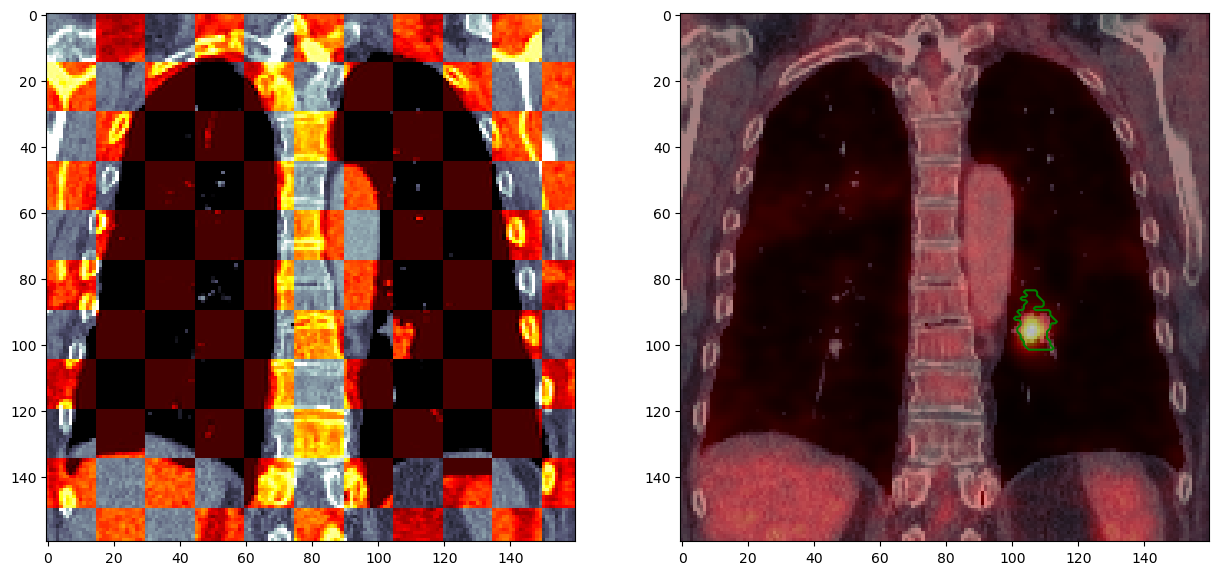

In [ ]:
# [160,128,160]
slc = np.s_[20:180, 16:144, 20:180]

res  = res[slc]
pct  = pctbb[slc]
plun = plunbb[slc]
itv  = itvbb[slc]
pt   = ptbb[slc]
lun  = lunbb[slc]

pattern = ch_filter(res.shape, 15)
rct_ch = np.where(pattern, res, np.nan)

fig, ax = plt.subplots(1,2, figsize=(15,8))
s = int(center_of_mass(itv)[1])
ax[0].imshow(pct[:,s,:], cmap="bone")
ax[0].imshow(rct_ch[:,s,:], cmap="hot")
ax[1].imshow(pct[:,s,:], cmap="bone")
ax[1].contour(itv[:,s,:], levels=[0.5], colors="green")
ax[1].imshow(pt[:,s,:], cmap="hot", alpha=0.5)

### Cut diaphram and evaluate registration result

In [ ]:
slc = np.s_[:-30,:,:]

pct = pct[slc]
res = res[slc]
plun = plun[slc]
lun = lun[slc]

ssim_score, _ = ssim(pct, res, data_range=600, full=True)
        
plts = torch.tensor(plun[None,None,...], dtype=torch.float32)
lts = torch.tensor(lun[None,None,...], dtype=torch.float32)

dice_m = DiceMetric(include_background=False)
dice = dice_m(lts, plts)

h95_m = HausdorffDistanceMetric(percentile=95, include_background=False)
h95 = h95_m(lts, plts)

# pcoms = [np.array(center_of_mass(pll)), np.array(center_of_mass(plr))]
# rcoms = [np.array(center_of_mass(rll)), np.array(center_of_mass(rlr))]

# left_tre = np.linalg.norm(pcoms[0] - rcoms[0])
# right_tre = np.linalg.norm(pcoms[1] - rcoms[1])

print(f'SSIM: {ssim_score}, Dice: {dice.item()}, H95: {h95.item()}')

SSIM: 0.43859855342230597, Dice: 0.9471320509910583, H95: 3.1622776985168457
